# Project 1: Star-Forming Main Sequence

**Difficulty:** Beginner  
**Time:** 20-25 minutes  
**ICARD-MU Workshop | Day 2**

---

## Learning Objectives
- Understand the **star-forming main sequence** (SFMS) - the fundamental relationship in galaxy evolution
- Learn to identify different galaxy populations:
  - **Main Sequence**: Normal star-forming galaxies
  - **Starburst**: Galaxies with elevated SFR
  - **Quiescent**: Galaxies with suppressed SFR
- Practice log-scale plotting and correlation analysis
- Calculate specific SFR (sSFR = SFR/Mass)

---

## Background

The **Star-Forming Main Sequence (SFMS)** is one of the most important relationships in galaxy evolution. It shows that most star-forming galaxies follow a tight relationship between their:
- **Stellar Mass** (M★)
- **Star Formation Rate** (SFR)

**Key equation:**  
$$\log(\text{SFR}) \sim \alpha \log(M_*) + \beta$$

Where α ≈ 0.8-1.0 (slope) and β depends on redshift.

Galaxies can be classified based on their position relative to this sequence!

## Step 1: Import Libraries and Load Data

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table
from astropy.io import fits
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Set nice plotting defaults
plt.rcParams['figure.figsize'] = (10, 8)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.linewidth'] = 1.5

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [3]:
# Load COSMOS-Web catalog
print("Loading COSMOS-Web master catalog...")
print("This may take a minute...\n")

catalog_path = '/Volumes/Ronaldo_SSD/COSMOSWEB/COSMOSWeb_mastercatalog_v1.fits'

with fits.open(catalog_path) as hdu:
    # Create master catalog
    master_catalog = Table()
    
    # HDU 1: Basic info
    print("Loading basic columns...")
    master_catalog['id'] = hdu[1].data['id']
    master_catalog['ra'] = hdu[1].data['ra'] 
    master_catalog['dec'] = hdu[1].data['dec']
    
    # HDU 2: LePhare - redshifts and physical parameters
    print("Loading LePhare columns...")
    master_catalog['z_best'] = hdu[2].data['zfinal']
    master_catalog['z_med'] = hdu[2].data['zpdf_med']
    master_catalog['mass'] = hdu[2].data['mass_med']  # log10(M☉)
    master_catalog['mass_l68'] = hdu[2].data['mass_l68']
    master_catalog['mass_u68'] = hdu[2].data['mass_u68']
    master_catalog['sfr'] = hdu[2].data['sfr_med']  # M☉/yr
    master_catalog['sfr_l68'] = hdu[2].data['sfr_l68']
    master_catalog['sfr_u68'] = hdu[2].data['sfr_u68']
    master_catalog['ssfr'] = hdu[2].data['ssfr_med']  # yr^-1
    master_catalog['chi2'] = hdu[2].data['chi2_best']

print(f"\n✓ Loaded {len(master_catalog)} galaxies")
print(f"✓ Columns: {master_catalog.colnames}")

Loading COSMOS-Web master catalog...
This may take a minute...

Loading basic columns...
Loading LePhare columns...

✓ Loaded 784016 galaxies
✓ Columns: ['id', 'ra', 'dec', 'z_best', 'z_med', 'mass', 'mass_l68', 'mass_u68', 'sfr', 'sfr_l68', 'sfr_u68', 'ssfr', 'chi2']


In [18]:
# Load COSMOS-Web catalog
print("Loading COSMOS-Web master catalog...")
print("This may take a minute...\n")

catalog_path = '/Volumes/Ronaldo_SSD/COSMOSWEB/COSMOSWeb_mastercatalog_v1.fits'

with fits.open(catalog_path) as hdu:
    # Create master catalog
    master_catalog = Table()
    
    # HDU 1: Basic info
    print("Loading basic columns...")
    master_catalog['id'] = hdu[1].data['id']
    master_catalog['ra'] = hdu[1].data['ra'] 
    master_catalog['dec'] = hdu[1].data['dec']
    
    # HDU 2: LePhare - redshifts and physical parameters
    print("Loading LePhare columns...")
    master_catalog['z_best'] = hdu[2].data['zfinal']
    master_catalog['z_med'] = hdu[2].data['zpdf_med']
    master_catalog['mass'] = hdu[2].data['mass_med']  # log10(M☉)
    master_catalog['mass_l68'] = hdu[2].data['mass_l68']
    master_catalog['mass_u68'] = hdu[2].data['mass_u68']
    master_catalog['sfr'] = hdu[2].data['sfr_med']  # M☉/yr
    master_catalog['sfr_l68'] = hdu[2].data['sfr_l68']
    master_catalog['sfr_u68'] = hdu[2].data['sfr_u68']
    master_catalog['ssfr'] = hdu[2].data['ssfr_med']  # yr^-1
    master_catalog['chi2'] = hdu[2].data['chi2_best']
    # HDU 2: LePhare - redshifts, physical parameters, and ABSOLUTE MAGNITUDES
    print("Loading LePhare columns...")
    master_catalog['z_best'] = hdu[2].data['zfinal']
    master_catalog['mass'] = hdu[2].data['mass_med']
    master_catalog['sfr'] = hdu[2].data['sfr_med']
    master_catalog['ssfr'] = hdu[2].data['ssfr_med']
    
    # Rest-frame absolute magnitudes from LePhare
    print("Loading rest-frame magnitudes...")
    master_catalog['M_NUV'] = hdu[2].data['mabs_nuv']  # Near-UV (proxy for U)
    master_catalog['M_r'] = hdu[2].data['mabs_r']      # R-band (proxy for V)
    master_catalog['M_J'] = hdu[2].data['mabs_j']      # J-band
    master_catalog['M_K'] = hdu[2].data['mabs_k']      # K-band


print(f"\n✓ Loaded {len(master_catalog)} galaxies")
print(f"✓ Columns: {master_catalog.colnames}")

Loading COSMOS-Web master catalog...
This may take a minute...

Loading basic columns...
Loading LePhare columns...
Loading LePhare columns...
Loading rest-frame magnitudes...

✓ Loaded 784016 galaxies
✓ Columns: ['id', 'ra', 'dec', 'z_best', 'z_med', 'mass', 'mass_l68', 'mass_u68', 'sfr', 'sfr_l68', 'sfr_u68', 'ssfr', 'chi2', 'M_NUV', 'M_r', 'M_J', 'M_K']


In [19]:
master_catalog[1]

id,ra,dec,z_best,z_med,mass,mass_l68,mass_u68,sfr,sfr_l68,sfr_u68,ssfr,chi2,M_NUV,M_r,M_J,M_K
int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
1,149.8614671527942,2.09408385222106,0.9261,0.9261,8.89948,8.85,8.93436,1.2,1.1,1.268,-7.69984,167.398,-18.56224,-20.04946,-21.12883,-20.80142


In [20]:
#Filter to 1.5 <= z_best <= 2.0 (inclusive)
import os
zmin, zmax = 1.5, 2.0
mask = (master_catalog['z_best'] >= zmin) & (master_catalog['z_best'] <= zmax)
filtered = master_catalog[mask]

print(f"Filtered to {len(filtered)} galaxies with {zmin} <= z_best <= {zmax}")
out_path = '/Users/ronaldolaishram/ReactCode/MUTalk/DAY2/COSMOSWeb_mastercatalog_z1.5-2.0.fits'

# Save to FITS (overwrite if file exists)
if os.path.exists(out_path):
    print(f"Overwriting existing file: {out_path}")
    os.remove(out_path)

# astropy.Table.write will create a PrimaryHDU + BinTableHDU
filtered.write(out_path, format='fits')

print(f"Saved filtered catalog to: {out_path}")

Filtered to 94798 galaxies with 1.5 <= z_best <= 2.0
Saved filtered catalog to: /Users/ronaldolaishram/ReactCode/MUTalk/DAY2/COSMOSWeb_mastercatalog_z1.5-2.0.fits


In [21]:
filtered

id,ra,dec,z_best,z_med,mass,mass_l68,mass_u68,sfr,sfr_l68,sfr_u68,ssfr,chi2,M_NUV,M_r,M_J,M_K
int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
2,149.81650742969083,2.111222325598279,1.865,1.865,8.04512,7.8044,8.23891,-0.47509,-0.71212,-0.22928,-8.5126,14.3079,-16.38266,-17.70433,-17.73541,-17.42897
3,149.75334444448737,2.1382707712401525,1.6833,1.6833,9.10093,9.06537,9.15,1.79813,1.7,1.86927,-7.30187,56.3374,-19.98842,-20.90562,-21.81576,-21.76859
8,149.83973922187937,2.111194073066386,1.5991,1.5991,8.28374,8.23281,8.38192,-0.2908,-0.37556,-0.2,-8.56587,32.9327,-18.09692,-18.45969,-18.31483,-17.55646
9,149.82133691072463,2.1179164727834983,1.8889,1.8889,8.46261,8.22543,8.5965,-0.1861,-0.38094,0.03105,-8.64761,4.98826,-17.37942,-18.33899,-18.77646,-18.26567
10,149.784907352127,2.131144564653922,1.755,1.755,8.68301,8.56945,8.78497,-0.06042,-0.24031,0.02093,-8.76202,16.3211,-17.62355,-18.73681,-19.13376,-18.54902
26,149.8143036699438,2.120687699936042,1.551,1.551,8.05863,7.83694,8.22072,-0.43556,-0.58475,-0.20752,-8.4896,7.80399,-16.87864,-17.74279,-17.61081,-17.03906
27,149.73454554917717,2.149686473340784,1.6732,1.6732,7.90398,7.69977,8.05259,-0.5913,-0.76766,-0.40971,-8.49269,21.4184,-16.23971,-17.67798,-17.55337,-17.00167
29,149.81004870318085,2.1222282571924977,1.6939,1.6939,8.7069,8.59735,8.79843,-0.03724,-0.27039,0.1215,-8.73599,17.0863,-17.88531,-19.01815,-19.23145,-18.54662
30,149.84463241535346,2.1097051284526134,1.639,1.639,7.90004,7.71748,8.06973,-0.41174,-0.55507,-0.23336,-8.29882,8.21477,-16.74847,-17.67656,-17.78343,-17.26701


## Step 2: Quality Control and Sample Selection

Before analyzing, we need to:
1. Remove bad measurements (NaN, -99, etc.)
2. Select reliable redshifts
3. Select star-forming galaxies (SFR > 0)
4. Apply mass and redshift cuts

In [12]:
# Create quality masks
print("Applying quality cuts...\n")

# 1. Valid measurements (not NaN or -99)
valid_mask = (
    (master_catalog['mass'] > 0) & 
    (master_catalog['mass'] < 20) &  # Reasonable mass range
    (master_catalog['sfr'] > -90) &  # Valid SFR (can be negative for log)
    (master_catalog['z_best'] > 1.5) &
    (master_catalog['z_best'] < 2.0) &
    np.isfinite(master_catalog['mass']) &
    np.isfinite(master_catalog['sfr']) &
    np.isfinite(master_catalog['z_best'])
)

print(f"Valid measurements: {np.sum(valid_mask)} / {len(master_catalog)}")

# 2. Redshift selection (0.5 < z < 3.0)
z_mask = (master_catalog['z_best'] > 0.5) & (master_catalog['z_best'] < 3.0)
print(f"Redshift 0.5-3.0: {np.sum(valid_mask & z_mask)}")

# 3. Mass completeness (log M > 9.0)
mass_mask = master_catalog['mass'] > 9.0
print(f"Mass > 10^9 M☉: {np.sum(valid_mask & z_mask & mass_mask)}")

# 4. Star-forming selection (log SFR > -2)
sf_mask = master_catalog['sfr'] > -2.0
print(f"Star-forming (SFR > 0.01 M☉/yr): {np.sum(valid_mask & z_mask & mass_mask & sf_mask)}")

# Combine all masks
final_mask = valid_mask & z_mask & mass_mask & sf_mask

# Create clean sample
clean_sample = master_catalog[final_mask]

print(f"\n✓ Final clean sample: {len(clean_sample)} galaxies")
print(f"✓ Fraction retained: {100*len(clean_sample)/len(master_catalog):.1f}%")

Applying quality cuts...

Valid measurements: 94747 / 784016
Redshift 0.5-3.0: 94747
Mass > 10^9 M☉: 18541
Star-forming (SFR > 0.01 M☉/yr): 18188

✓ Final clean sample: 18188 galaxies
✓ Fraction retained: 2.3%


## Step 3: Plot the Star-Forming Main Sequence

Let's create a beautiful density plot of SFR vs Stellar Mass!

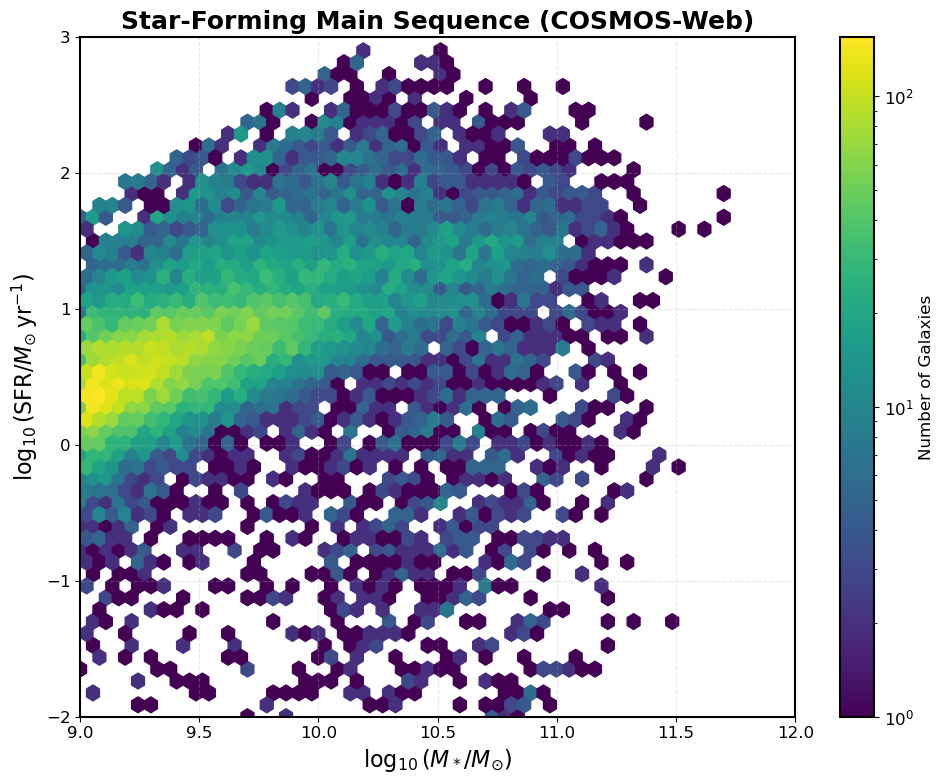


Question: What do you notice about the distribution?
Is there a clear relationship between mass and SFR?


In [13]:
# Extract data
log_mass = clean_sample['mass']  # Already in log10(M☉)
log_sfr = clean_sample['sfr']    # Already in log10(M☉/yr)

# Create figure
fig, ax = plt.subplots(figsize=(10, 8))

# Hexbin plot (density plot)
hexbin = ax.hexbin(log_mass, log_sfr, 
                   gridsize=50, 
                   cmap='viridis', 
                   mincnt=1,
                   bins='log')

# Add colorbar
cbar = plt.colorbar(hexbin, ax=ax, label='Number of Galaxies')

# Labels
ax.set_xlabel(r'$\log_{10}(M_* / M_{\odot})$', fontsize=16)
ax.set_ylabel(r'$\log_{10}(\mathrm{SFR} / M_{\odot}\,\mathrm{yr}^{-1})$', fontsize=16)
ax.set_title('Star-Forming Main Sequence (COSMOS-Web)', fontsize=18, fontweight='bold')

# Set limits
ax.set_xlim(9, 12)
ax.set_ylim(-2, 3)

# Add grid
ax.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

print("\nQuestion: What do you notice about the distribution?")
print("Is there a clear relationship between mass and SFR?")

## Step 4: Fit the Main Sequence

Let's fit a line to find the SFMS relationship!

In [14]:
# Robust fitting using median in mass bins
mass_bins = np.arange(9.0, 12.0, 0.2)
mass_centers = []
sfr_medians = []
sfr_stds = []

for i in range(len(mass_bins)-1):
    mask = (log_mass >= mass_bins[i]) & (log_mass < mass_bins[i+1])
    if np.sum(mask) > 10:  # Need enough galaxies
        mass_centers.append(0.5 * (mass_bins[i] + mass_bins[i+1]))
        sfr_medians.append(np.median(log_sfr[mask]))
        sfr_stds.append(np.std(log_sfr[mask]))

mass_centers = np.array(mass_centers)
sfr_medians = np.array(sfr_medians)
sfr_stds = np.array(sfr_stds)

# Fit linear relation
slope, intercept, r_value, p_value, std_err = stats.linregress(mass_centers, sfr_medians)

print("Star-Forming Main Sequence Fit:")
print(f"log(SFR) = {slope:.3f} × log(M*) + {intercept:.3f}")
print(f"R² = {r_value**2:.3f}")
print(f"Scatter = {np.mean(sfr_stds):.3f} dex")

# Calculate main sequence line
mass_fit = np.linspace(9, 12, 100)
sfr_fit = slope * mass_fit + intercept

Star-Forming Main Sequence Fit:
log(SFR) = 0.268 × log(M*) + -1.758
R² = 0.486
Scatter = 0.740 dex


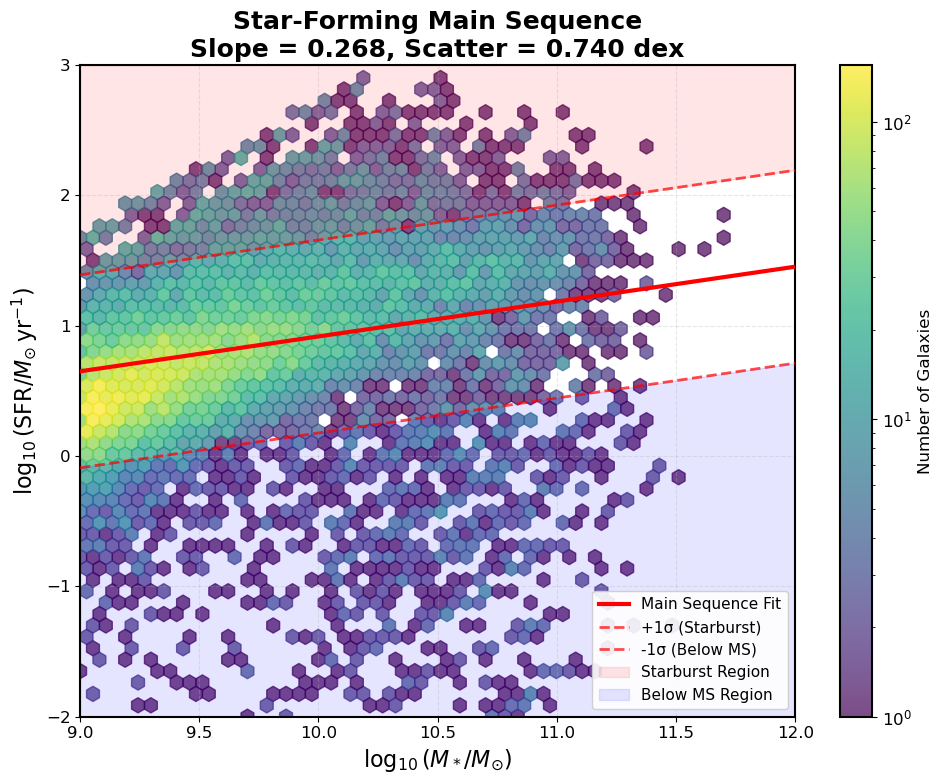

In [15]:
# Plot with fitted main sequence
fig, ax = plt.subplots(figsize=(10, 8))

# Hexbin plot
hexbin = ax.hexbin(log_mass, log_sfr, 
                   gridsize=50, 
                   cmap='viridis', 
                   mincnt=1,
                   bins='log',
                   alpha=0.7)

# Plot fitted main sequence
ax.plot(mass_fit, sfr_fit, 'r-', linewidth=3, label='Main Sequence Fit', zorder=10)

# Plot ±1σ scatter
scatter = np.mean(sfr_stds)
ax.plot(mass_fit, sfr_fit + scatter, 'r--', linewidth=2, alpha=0.7, label='+1σ (Starburst)', zorder=10)
ax.plot(mass_fit, sfr_fit - scatter, 'r--', linewidth=2, alpha=0.7, label='-1σ (Below MS)', zorder=10)

# Shade starburst and quiescent regions
ax.fill_between(mass_fit, sfr_fit + scatter, 3, alpha=0.1, color='red', label='Starburst Region')
ax.fill_between(mass_fit, -2, sfr_fit - scatter, alpha=0.1, color='blue', label='Below MS Region')

# Add colorbar
cbar = plt.colorbar(hexbin, ax=ax, label='Number of Galaxies')

# Labels
ax.set_xlabel(r'$\log_{10}(M_* / M_{\odot})$', fontsize=16)
ax.set_ylabel(r'$\log_{10}(\mathrm{SFR} / M_{\odot}\,\mathrm{yr}^{-1})$', fontsize=16)
ax.set_title(f'Star-Forming Main Sequence\nSlope = {slope:.3f}, Scatter = {scatter:.3f} dex', 
             fontsize=18, fontweight='bold')

ax.set_xlim(9, 12)
ax.set_ylim(-2, 3)
ax.legend(loc='lower right', fontsize=11, framealpha=0.9)
ax.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

## Step 5: Classify Galaxies

Now let's classify galaxies based on their distance from the main sequence!

In [16]:
# Calculate expected SFR on main sequence for each galaxy
expected_sfr = slope * log_mass + intercept

# Calculate offset from main sequence (Delta_MS)
delta_ms = log_sfr - expected_sfr

# Classify galaxies
starburst_mask = delta_ms > scatter
main_sequence_mask = (delta_ms >= -scatter) & (delta_ms <= scatter)
below_ms_mask = delta_ms < -scatter

n_starburst = np.sum(starburst_mask)
n_ms = np.sum(main_sequence_mask)
n_below = np.sum(below_ms_mask)

print("Galaxy Classification:")
print(f"  Starburst (>+1σ):     {n_starburst:5d} ({100*n_starburst/len(clean_sample):.1f}%)")
print(f"  Main Sequence (±1σ):  {n_ms:5d} ({100*n_ms/len(clean_sample):.1f}%)")
print(f"  Below MS (<-1σ):      {n_below:5d} ({100*n_below/len(clean_sample):.1f}%)")
print(f"  Total:                {len(clean_sample):5d}")

Galaxy Classification:
  Starburst (>+1σ):      1434 (7.9%)
  Main Sequence (±1σ):  15326 (84.3%)
  Below MS (<-1σ):       1428 (7.9%)
  Total:                18188


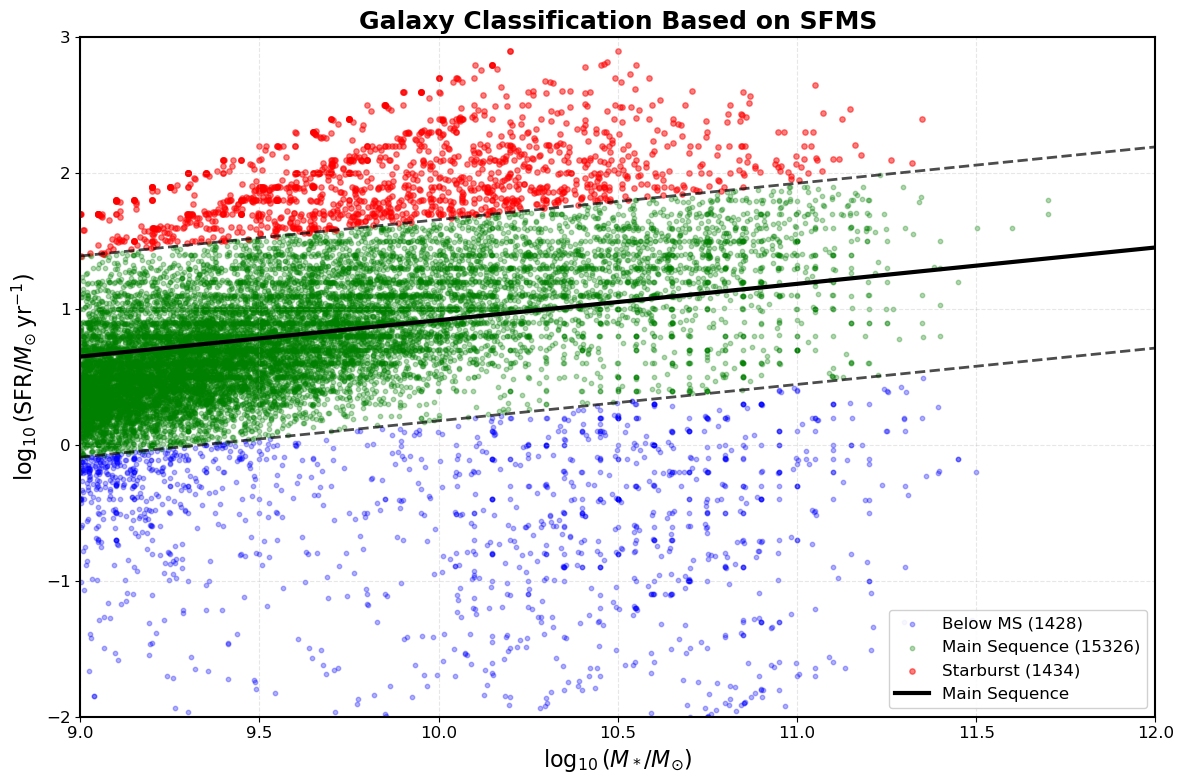

In [17]:
# Plot classified galaxies
fig, ax = plt.subplots(figsize=(12, 8))

# Plot each population
ax.scatter(log_mass[below_ms_mask], log_sfr[below_ms_mask], 
           c='blue', s=10, alpha=0.3, label=f'Below MS ({n_below})', rasterized=True)
ax.scatter(log_mass[main_sequence_mask], log_sfr[main_sequence_mask], 
           c='green', s=10, alpha=0.3, label=f'Main Sequence ({n_ms})', rasterized=True)
ax.scatter(log_mass[starburst_mask], log_sfr[starburst_mask], 
           c='red', s=15, alpha=0.5, label=f'Starburst ({n_starburst})', rasterized=True)

# Plot main sequence
ax.plot(mass_fit, sfr_fit, 'k-', linewidth=3, label='Main Sequence')
ax.plot(mass_fit, sfr_fit + scatter, 'k--', linewidth=2, alpha=0.7)
ax.plot(mass_fit, sfr_fit - scatter, 'k--', linewidth=2, alpha=0.7)

ax.set_xlabel(r'$\log_{10}(M_* / M_{\odot})$', fontsize=16)
ax.set_ylabel(r'$\log_{10}(\mathrm{SFR} / M_{\odot}\,\mathrm{yr}^{-1})$', fontsize=16)
ax.set_title('Galaxy Classification Based on SFMS', fontsize=18, fontweight='bold')
ax.set_xlim(9, 12)
ax.set_ylim(-2, 3)
ax.legend(loc='lower right', fontsize=12, framealpha=0.9)
ax.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

## Step 6: Specific SFR (sSFR) Analysis

The **specific SFR** = SFR / M★ tells us how fast a galaxy is growing relative to its current mass.

sSFR = 1/10 Gyr means the galaxy doubles its mass every 10 Gyr.

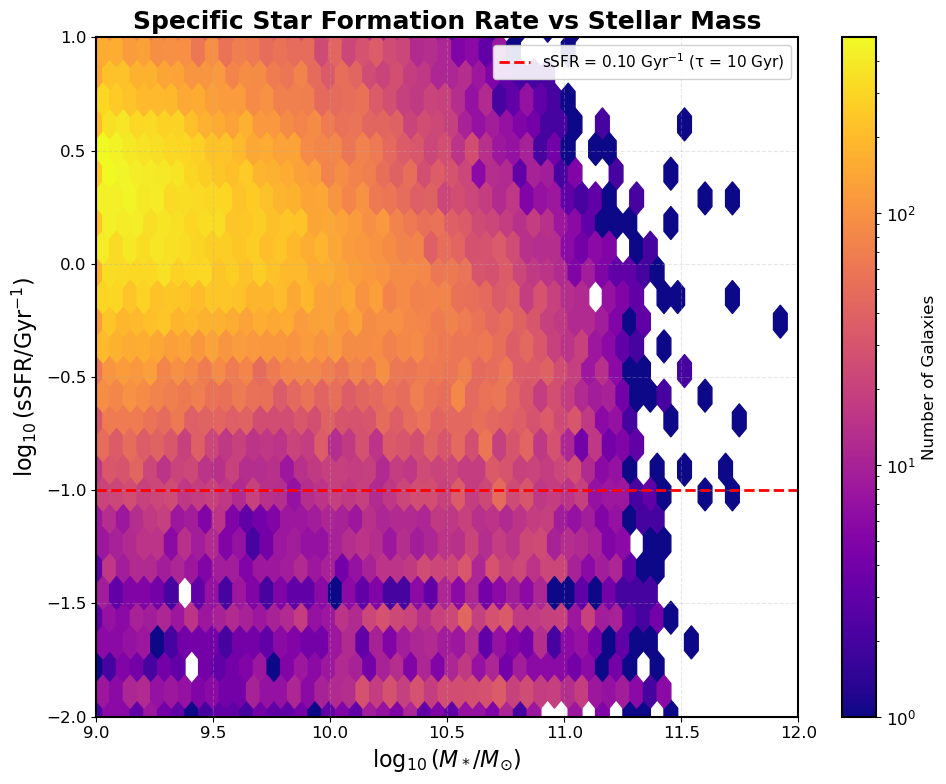


Question: How does sSFR change with mass?
What does this tell us about galaxy growth?


In [10]:
# Calculate sSFR (already in catalog, but let's verify)
log_ssfr = log_sfr - log_mass  # log(SFR/M*) = log(SFR) - log(M*)

# Convert to Gyr^-1 units (from yr^-1)
log_ssfr_Gyr = log_ssfr + 9  # Add 9 to convert yr^-1 to Gyr^-1

# Plot sSFR vs Mass
fig, ax = plt.subplots(figsize=(10, 8))

hexbin = ax.hexbin(log_mass, log_ssfr_Gyr, 
                   gridsize=50, 
                   cmap='plasma', 
                   mincnt=1,
                   bins='log')

cbar = plt.colorbar(hexbin, ax=ax, label='Number of Galaxies')

# Add reference lines
ssfr_ref = -1.0  # 0.1 Gyr^-1 = doubles mass every 10 Gyr
ax.axhline(ssfr_ref, color='red', linestyle='--', linewidth=2, 
           label=f'sSFR = {10**ssfr_ref:.2f} Gyr$^{{-1}}$ (τ = 10 Gyr)')

ax.set_xlabel(r'$\log_{10}(M_* / M_{\odot})$', fontsize=16)
ax.set_ylabel(r'$\log_{10}(\mathrm{sSFR} / \mathrm{Gyr}^{-1})$', fontsize=16)
ax.set_title('Specific Star Formation Rate vs Stellar Mass', fontsize=18, fontweight='bold')
ax.set_xlim(9, 12)
ax.set_ylim(-2, 1)
ax.legend(loc='upper right', fontsize=11, framealpha=0.9)
ax.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

print("\nQuestion: How does sSFR change with mass?")
print("What does this tell us about galaxy growth?")

## Step 7: Summary Statistics

In [11]:
print("="*60)
print("PROJECT 1 SUMMARY: Star-Forming Main Sequence")
print("="*60)
print(f"\nSample: {len(clean_sample)} galaxies (0.5 < z < 3.0)")
print(f"\nMain Sequence Fit:")
print(f"  log(SFR) = {slope:.3f} × log(M*) + {intercept:.3f}")
print(f"  Scatter: {scatter:.3f} dex")
print(f"  R²: {r_value**2:.3f}")
print(f"\nGalaxy Populations:")
print(f"  Starburst:      {n_starburst:5d} ({100*n_starburst/len(clean_sample):.1f}%)")
print(f"  Main Sequence:  {n_ms:5d} ({100*n_ms/len(clean_sample):.1f}%)")
print(f"  Below MS:       {n_below:5d} ({100*n_below/len(clean_sample):.1f}%)")
print(f"\nMedian sSFR: {np.median(10**log_ssfr_Gyr):.3f} Gyr^-1")
print(f"Doubling time: {1/np.median(10**log_ssfr_Gyr):.2f} Gyr")
print("\n" + "="*60)

PROJECT 1 SUMMARY: Star-Forming Main Sequence

Sample: 75238 galaxies (0.5 < z < 3.0)

Main Sequence Fit:
  log(SFR) = 0.082 × log(M*) + -0.005
  Scatter: 0.831 dex
  R²: 0.062

Galaxy Populations:
  Starburst:       5660 (7.5%)
  Main Sequence:  60137 (79.9%)
  Below MS:        9441 (12.5%)

Median sSFR: 1.280 Gyr^-1
Doubling time: 0.78 Gyr



## Discussion Questions

1. **Why is the SFMS important in galaxy evolution?**
   - What physical processes might regulate this relationship?

2. **What causes galaxies to be above/below the main sequence?**
   - Starburst triggers?
   - Quenching mechanisms?

3. **How might the SFMS evolve with redshift?**
   - Should the slope or normalization change?
   - Why?

4. **What does the scatter in the SFMS tell us?**
   - Is it measurement uncertainty or real variation?

---

## Next Steps

Try modifying this analysis:
- Select different redshift ranges
- Compare LePhare vs CIGALE SFRs
- Add morphology information
- Investigate what drives starburst galaxies

**Ready for Project 2? Let's explore UVJ color-color diagrams!**